# MNIST Handwritten Digit Classification using CNN and RNN (PyTorch)
### Comparative Analysis of Convolutional Neural Networks and Recurrent Neural Networks
**Author:** Aadil Shaikh


## Table of Contents
1. [Introduction](#1.-Introduction)
2. [Project Objectives](#2.-Project-Objectives)
3. [Import Libraries](#3.-Import-Libraries)
4. [Load Dataset](#4.-Load-Dataset)
5. [Data Visualization](#5.-Data-Visualization)
6. [Data Preprocessing](#6.-Data-Preprocessing)
7. [CNN Architecture](#7.-CNN-Architecture)
8. [CNN Training](#8.-CNN-Training)
9. [CNN Evaluation](#9.-CNN-Evaluation)
10. [RNN Architecture](#10.-RNN-Architecture)
11. [RNN Training](#11.-RNN-Training)
12. [RNN Evaluation](#12.-RNN-Evaluation)
13. [CNN vs RNN Comparison](#13.-CNN-vs-RNN-Comparison)
14. [Results](#14.-Results)
15. [Conclusion](#15.-Conclusion)
16. [Future Improvements](#16.-Future-Improvements)


## 1. Introduction
The MNIST dataset is a large database of handwritten digits that is commonly used for training various image processing systems. This project explores the application of two fundamentally different neural network architectures—Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs)—to classify these handwritten digits. While CNNs are the standard for image data due to their spatial feature extraction capabilities, RNNs, which process data sequentially, can also be applied by treating an image as a sequence of pixel rows.


## 2. Project Objectives
- Build, train, and evaluate a CNN model for MNIST digit classification.
- Build, train, and evaluate an RNN model for the same task.
- Compare both models based on accuracy, loss, training time, inference time, and parameter count.
- Implement reusable functions for training, evaluation, and visualization.
- Save metrics, models, and performance visualizations automatically.


## 3. Import Libraries
We use PyTorch as our deep learning framework, along with torchvision for dataset handling. Matplotlib and Seaborn are used for visualizations, and scikit-learn for evaluation metrics.


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Create necessary directories
directories = ['images', 'outputs', 'models']
for d in directories:
    os.makedirs(d, exist_ok=True)
    print(f"Directory '{d}/' is ready.")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)


Directory 'images/' is ready.
Directory 'outputs/' is ready.
Directory 'models/' is ready.


In [3]:
# Device configuration (CUDA, MPS, or CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Running on: {str(device).upper()}")


Running on: CPU


## 4. Load Dataset
We load the MNIST dataset from `torchvision.datasets`.


In [4]:
batch_size = 64

# Define basic transform (to tensor) for initial visualization
# We will apply normalization later in preprocessing
basic_transform = transforms.ToTensor()

train_dataset_raw = datasets.MNIST(root='./data', train=True, download=True, transform=basic_transform)
test_dataset_raw = datasets.MNIST(root='./data', train=False, download=True, transform=basic_transform)

print(f"Training Images: {len(train_dataset_raw)}")
print(f"Testing Images:  {len(test_dataset_raw)}")


Training Images: 60000
Testing Images:  10000


## 5. Data Visualization
Let's visualize a few samples from our training dataset.


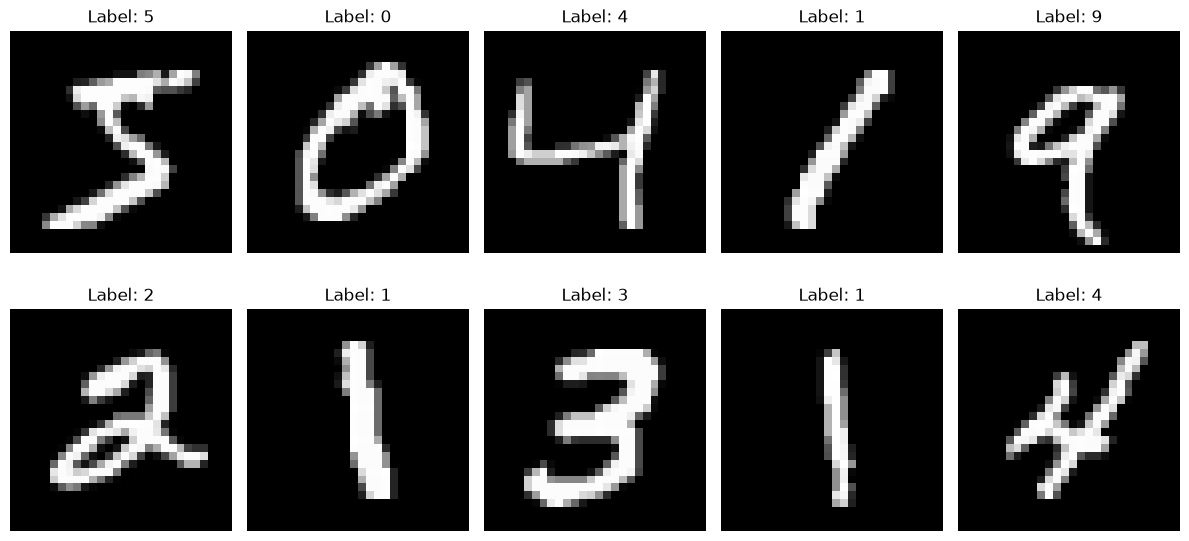

In [5]:
def visualize_samples(dataset, num_samples=10, save_path=None):
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        image, label = dataset[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

visualize_samples(train_dataset_raw, save_path='images/dataset_samples.png')


## 6. Data Preprocessing
We apply normalization to the dataset, scaling pixel values to a range of [-1, 1], which helps the neural networks converge faster.


In [6]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Reload dataset with full transforms
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

image, label = train_dataset[0]
print(f"Image Shape: {image.shape}")
print(f"Label: {label}")


Image Shape: torch.Size([1, 28, 28])
Label: 5


## 7. CNN Architecture
A Convolutional Neural Network (CNN) leverages spatial information through filters (kernels), making it highly effective for image classification tasks.


In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

cnn_model = CNN().to(device)
print(cnn_model)

# Calculate total trainable parameters
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters (CNN): {cnn_params:,}")


CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total Trainable Parameters (CNN): 421,642


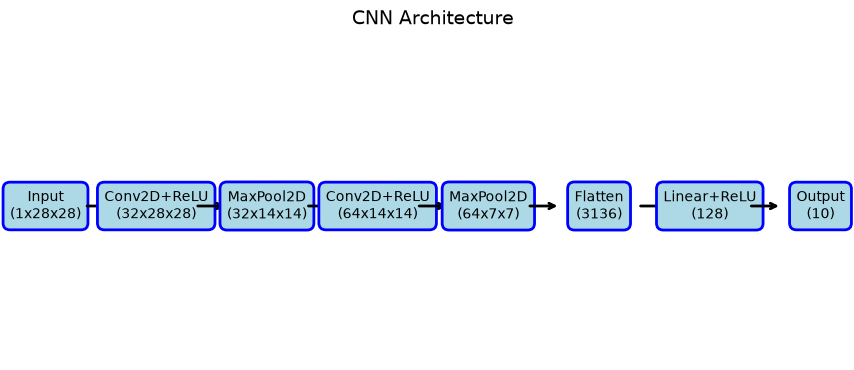

In [8]:
def draw_cnn_architecture(save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('off')
    
    layers = ['Input\n(1x28x28)', 'Conv2D+ReLU\n(32x28x28)', 'MaxPool2D\n(32x14x14)', 
              'Conv2D+ReLU\n(64x14x14)', 'MaxPool2D\n(64x7x7)', 'Flatten\n(3136)', 
              'Linear+ReLU\n(128)', 'Output\n(10)']
    
    x_positions = np.linspace(0, 1, len(layers))
    
    for i, (layer, x) in enumerate(zip(layers, x_positions)):
        bbox_props = dict(boxstyle="round,pad=0.5", fc="lightblue", ec="b", lw=2)
        ax.text(x, 0.5, layer, ha="center", va="center", size=10, bbox=bbox_props)
        if i < len(layers) - 1:
            ax.annotate('', xy=(x_positions[i+1]-0.05, 0.5), xytext=(x+0.05, 0.5),
                        arrowprops=dict(arrowstyle="->", lw=2))
            
    plt.title("CNN Architecture", fontsize=14, pad=20)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

draw_cnn_architecture('images/cnn_architecture.png')


## 8. CNN Training
We define reusable training and evaluation loops.


In [9]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, model_name, is_rnn=False):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            if is_rnn:
                images = images.squeeze(1) # RNN expects (batch, seq_len, input_size)
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                if is_rnn:
                    images = images.squeeze(1)
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        epoch_val_loss = val_loss / len(test_loader.dataset)
        epoch_val_acc = 100 * val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")
        
    training_time = time.time() - start_time
    print(f"\n{model_name} Training Completed in {training_time:.2f} seconds.")
    
    # Save model
    torch.save(model.state_dict(), f"models/{model_name.lower()}_model.pth")
    
    history = {
        'train_loss': train_losses,
        'train_acc': train_accuracies,
        'val_loss': val_losses,
        'val_acc': val_accuracies,
        'training_time': training_time
    }
    return history

def plot_training_history(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    plt.title(f'{model_name} Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'images/{model_name.lower()}_loss.png', dpi=300, bbox_inches="tight")
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='o')
    plt.title(f'{model_name} Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'images/{model_name.lower()}_accuracy.png', dpi=300, bbox_inches="tight")
    plt.show()


Epoch [1/10] - Train Loss: 0.1693, Train Acc: 94.83% | Val Loss: 0.0521, Val Acc: 98.36%
Epoch [2/10] - Train Loss: 0.0485, Train Acc: 98.50% | Val Loss: 0.0406, Val Acc: 98.68%
Epoch [3/10] - Train Loss: 0.0334, Train Acc: 98.98% | Val Loss: 0.0308, Val Acc: 99.11%
Epoch [4/10] - Train Loss: 0.0251, Train Acc: 99.18% | Val Loss: 0.0328, Val Acc: 98.90%
Epoch [5/10] - Train Loss: 0.0189, Train Acc: 99.41% | Val Loss: 0.0292, Val Acc: 99.01%
Epoch [6/10] - Train Loss: 0.0154, Train Acc: 99.50% | Val Loss: 0.0332, Val Acc: 98.99%
Epoch [7/10] - Train Loss: 0.0115, Train Acc: 99.60% | Val Loss: 0.0313, Val Acc: 99.16%
Epoch [8/10] - Train Loss: 0.0102, Train Acc: 99.64% | Val Loss: 0.0292, Val Acc: 99.20%
Epoch [9/10] - Train Loss: 0.0074, Train Acc: 99.76% | Val Loss: 0.0312, Val Acc: 99.08%
Epoch [10/10] - Train Loss: 0.0076, Train Acc: 99.76% | Val Loss: 0.0357, Val Acc: 99.05%

CNN Training Completed in 713.68 seconds.


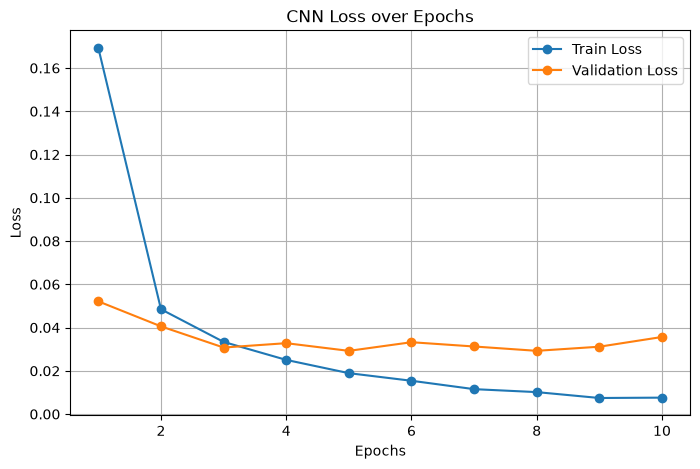

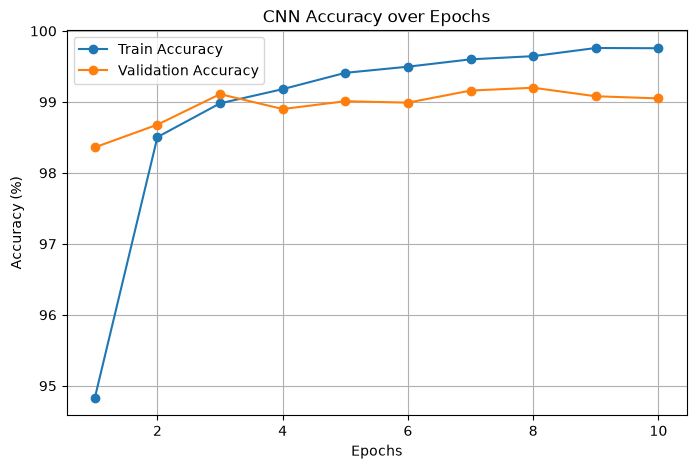

In [10]:
# Train CNN
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
epochs = 10

cnn_history = train_model(cnn_model, train_loader, test_loader, cnn_criterion, cnn_optimizer, epochs, "CNN")
plot_training_history(cnn_history, "CNN")


## 9. CNN Evaluation
We evaluate the CNN on the test set, plot the confusion matrix, and display the classification report.


CNN Inference Time: 18.6093 seconds

--- CNN Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



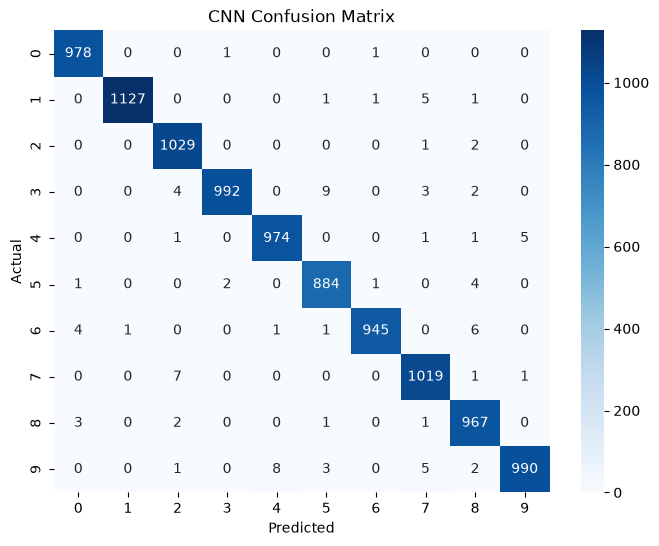

In [11]:
def evaluate_model(model, test_loader, model_name, is_rnn=False):
    model.eval()
    all_preds, all_labels = [], []
    
    start_time = time.time()
    with torch.no_grad():
        for images, labels in test_loader:
            if is_rnn:
                images = images.squeeze(1)
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    inference_time = time.time() - start_time
    print(f"{model_name} Inference Time: {inference_time:.4f} seconds")
    
    # Classification Report
    print(f"\n--- {model_name} Classification Report ---")
    report = classification_report(all_labels, all_preds, output_dict=True)
    print(classification_report(all_labels, all_preds))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'images/{model_name.lower()}_confusion_matrix.png', dpi=300, bbox_inches="tight")
    plt.show()
    
    return report, inference_time, all_preds, all_labels

cnn_report, cnn_infer_time, cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader, "CNN")


CNN Predictions:


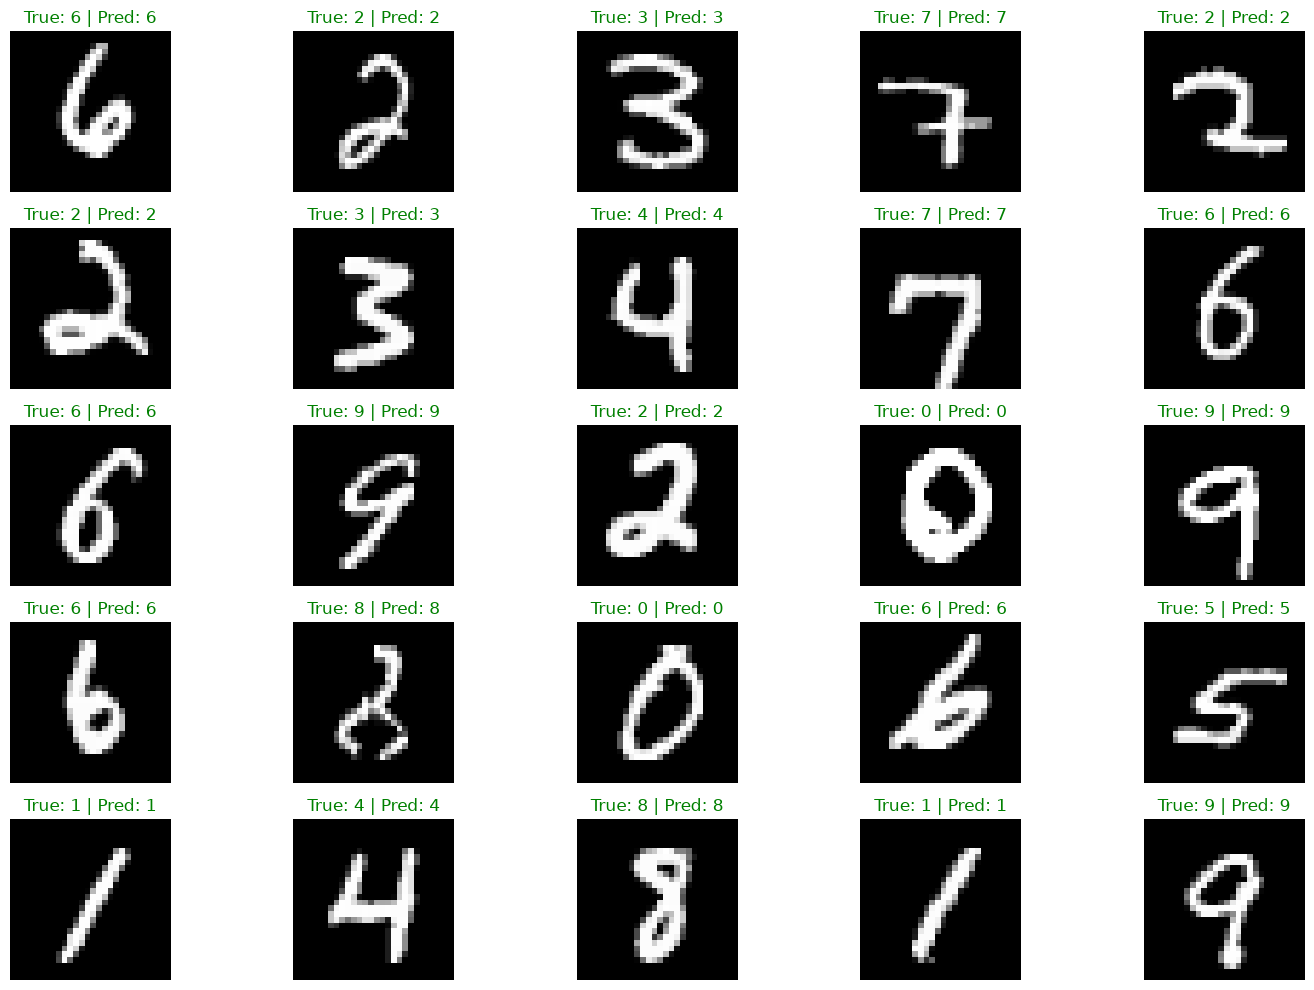

In [12]:
def visualize_predictions(dataset, predictions, num_samples=25, save_path=None):
    plt.figure(figsize=(15, 10))
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        image, true_label = dataset[idx]
        pred_label = predictions[idx]
        
        plt.subplot(5, 5, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label} | Pred: {pred_label}", color=color)
        plt.axis("off")
        
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print("CNN Predictions:")
visualize_predictions(test_dataset_raw, cnn_preds, save_path='images/prediction_examples.png')


## 10. RNN Architecture
Recurrent Neural Networks (RNNs) process data sequentially. For images, we treat the 28x28 image as a sequence of 28 timesteps, where each timestep is a row of 28 pixels.


In [13]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.hidden_size = 128
        self.num_layers = 2
        
        self.rnn = nn.RNN(
            input_size=28,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(self.hidden_size, 10)

    def forward(self, x):
        # x shape: (batch_size, seq_len=28, input_size=28)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :] # Take the output of the last timestep
        out = self.fc(out)
        return out

rnn_model = RNN().to(device)
print(rnn_model)

# Calculate total trainable parameters
rnn_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters (RNN): {rnn_params:,}")


RNN(
  (rnn): RNN(28, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)

Total Trainable Parameters (RNN): 54,538


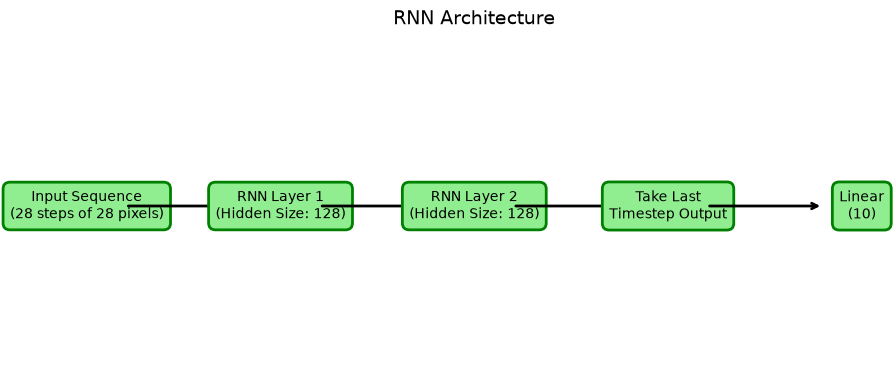

In [14]:
def draw_rnn_architecture(save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('off')
    
    layers = ['Input Sequence\n(28 steps of 28 pixels)', 'RNN Layer 1\n(Hidden Size: 128)', 
              'RNN Layer 2\n(Hidden Size: 128)', 'Take Last\nTimestep Output', 'Linear\n(10)']
    
    x_positions = np.linspace(0, 1, len(layers))
    
    for i, (layer, x) in enumerate(zip(layers, x_positions)):
        bbox_props = dict(boxstyle="round,pad=0.5", fc="lightgreen", ec="g", lw=2)
        ax.text(x, 0.5, layer, ha="center", va="center", size=10, bbox=bbox_props)
        if i < len(layers) - 1:
            ax.annotate('', xy=(x_positions[i+1]-0.05, 0.5), xytext=(x+0.05, 0.5),
                        arrowprops=dict(arrowstyle="->", lw=2))
            
    plt.title("RNN Architecture", fontsize=14, pad=20)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

draw_rnn_architecture('images/rnn_architecture.png')


## 11. RNN Training
We train the RNN model using the same reusable functions.


Epoch [1/10] - Train Loss: 0.6098, Train Acc: 79.63% | Val Loss: 0.3159, Val Acc: 90.27%
Epoch [2/10] - Train Loss: 0.2700, Train Acc: 92.05% | Val Loss: 0.2104, Val Acc: 93.96%
Epoch [3/10] - Train Loss: 0.1942, Train Acc: 94.22% | Val Loss: 0.2458, Val Acc: 92.92%
Epoch [4/10] - Train Loss: 0.1627, Train Acc: 95.27% | Val Loss: 0.1299, Val Acc: 96.24%
Epoch [5/10] - Train Loss: 0.1473, Train Acc: 95.77% | Val Loss: 0.1754, Val Acc: 95.26%
Epoch [6/10] - Train Loss: 0.1342, Train Acc: 96.18% | Val Loss: 0.1683, Val Acc: 94.90%
Epoch [7/10] - Train Loss: 0.1404, Train Acc: 96.06% | Val Loss: 0.1468, Val Acc: 95.69%
Epoch [8/10] - Train Loss: 0.1170, Train Acc: 96.64% | Val Loss: 0.1293, Val Acc: 96.18%
Epoch [9/10] - Train Loss: 0.1195, Train Acc: 96.62% | Val Loss: 0.1167, Val Acc: 96.86%
Epoch [10/10] - Train Loss: 0.1904, Train Acc: 94.45% | Val Loss: 0.1354, Val Acc: 96.33%

RNN Training Completed in 735.70 seconds.


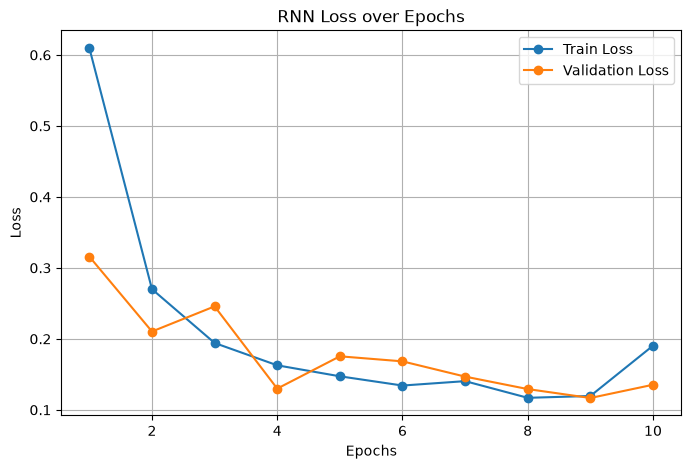

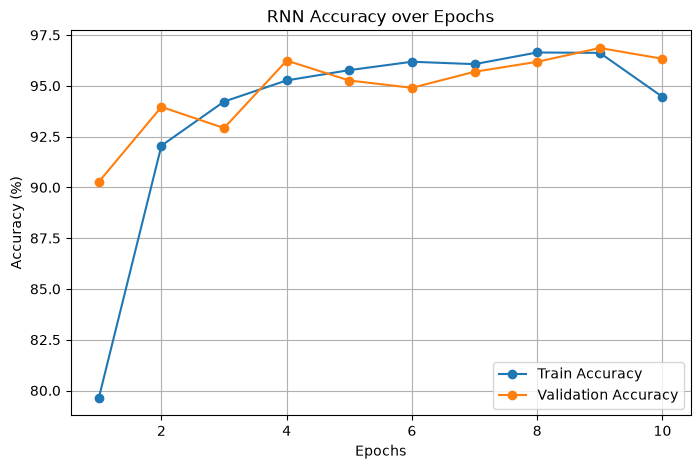

In [15]:
rnn_criterion = nn.CrossEntropyLoss()
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

rnn_history = train_model(rnn_model, train_loader, test_loader, rnn_criterion, rnn_optimizer, epochs, "RNN", is_rnn=True)
plot_training_history(rnn_history, "RNN")


## 12. RNN Evaluation
Evaluation metrics, classification report, and confusion matrix for the RNN.


RNN Inference Time: 6.4408 seconds

--- RNN Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.95      0.96      0.96      1032
           3       0.96      0.97      0.97      1010
           4       0.98      0.93      0.95       982
           5       0.93      0.95      0.94       892
           6       0.97      0.96      0.97       958
           7       0.96      0.98      0.97      1028
           8       0.98      0.95      0.96       974
           9       0.93      0.95      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



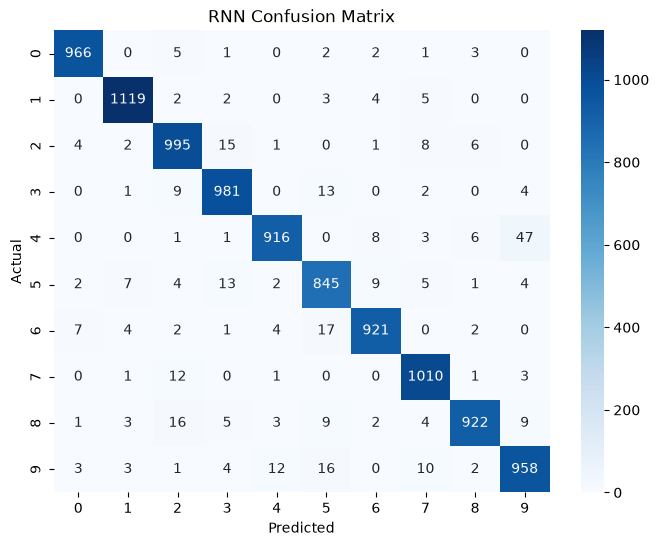

RNN Predictions:


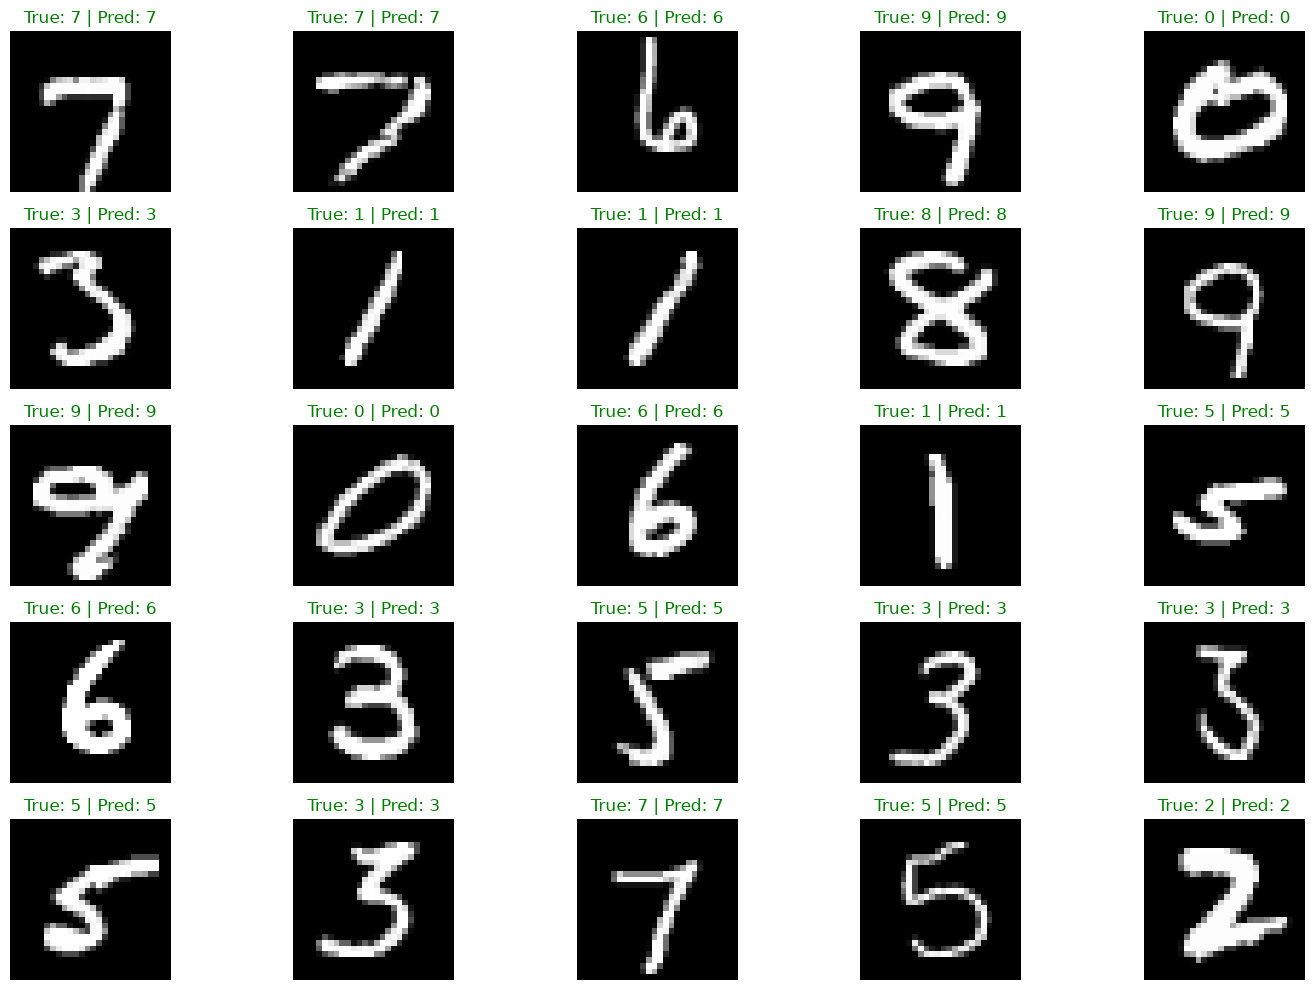

In [16]:
rnn_report, rnn_infer_time, rnn_preds, rnn_labels = evaluate_model(rnn_model, test_loader, "RNN", is_rnn=True)

print("RNN Predictions:")
visualize_predictions(test_dataset_raw, rnn_preds, save_path='images/prediction_examples_rnn.png')


## 13. CNN vs RNN Comparison
We now compare the performance of both models across various metrics and save the results into a CSV file.


In [17]:
# Compile metrics
comparison_data = {
    'Metric': ['Test Accuracy (%)', 'Test Loss', 'Precision (macro)', 'Recall (macro)', 'F1 Score (macro)', 
               'Trainable Parameters', 'Training Time (s)', 'Inference Time (s)'],
    'CNN': [
        cnn_history['val_acc'][-1],
        cnn_history['val_loss'][-1],
        cnn_report['macro avg']['precision'],
        cnn_report['macro avg']['recall'],
        cnn_report['macro avg']['f1-score'],
        cnn_params,
        cnn_history['training_time'],
        cnn_infer_time
    ],
    'RNN': [
        rnn_history['val_acc'][-1],
        rnn_history['val_loss'][-1],
        rnn_report['macro avg']['precision'],
        rnn_report['macro avg']['recall'],
        rnn_report['macro avg']['f1-score'],
        rnn_params,
        rnn_history['training_time'],
        rnn_infer_time
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison.to_csv('outputs/model_comparison.csv', index=False)
display(df_comparison)


,Metric,CNN,RNN
0,Test Accuracy (%),99.050000,96.330000
1,Test Loss,0.035651,0.135363
2,Precision (macro),0.990386,0.963142
3,Recall (macro),0.990472,0.962709
4,F1 Score (macro),0.990405,0.962820
5,Trainable Parameters,421642.000000,54538.000000
6,Training Time (s),713.683293,735.700135
7,Inference Time (s),18.609320,6.440760


## 14. Results & Visual Comparison
Charts illustrating the comparative performance of CNN and RNN.


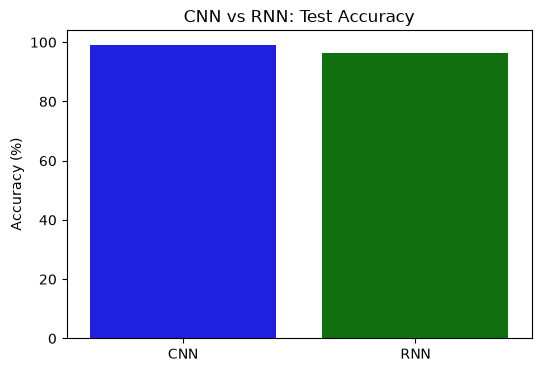

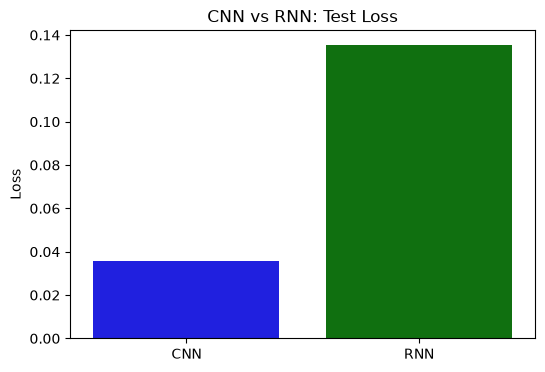

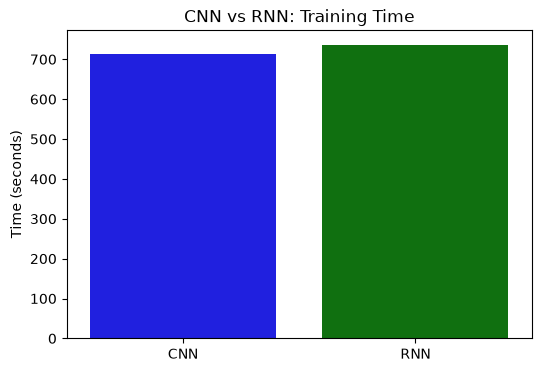

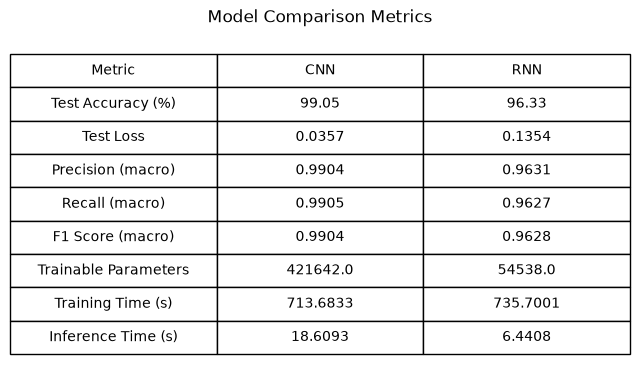

In [18]:
def plot_comparison_bar(df, metric, title, ylabel, save_path):
    plt.figure(figsize=(6, 4))
    row = df[df['Metric'] == metric].iloc[0]
    sns.barplot(x=['CNN', 'RNN'], y=[row['CNN'], row['RNN']], palette=['blue', 'green'])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_comparison_bar(df_comparison, 'Test Accuracy (%)', 'CNN vs RNN: Test Accuracy', 'Accuracy (%)', 'images/cnn_vs_rnn_accuracy.png')
plot_comparison_bar(df_comparison, 'Test Loss', 'CNN vs RNN: Test Loss', 'Loss', 'images/cnn_vs_rnn_loss.png')
plot_comparison_bar(df_comparison, 'Training Time (s)', 'CNN vs RNN: Training Time', 'Time (seconds)', 'images/cnn_vs_rnn_training_time.png')

# Save DataFrame as an image table
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_comparison.round(4).values, colLabels=df_comparison.columns, loc='center', cellLoc='center')
table.scale(1, 2)
plt.title("Model Comparison Metrics", pad=20)
plt.savefig('images/model_comparison.png', dpi=300, bbox_inches="tight")
plt.show()


## 15. Workflow Diagram
A visual representation of our project workflow.


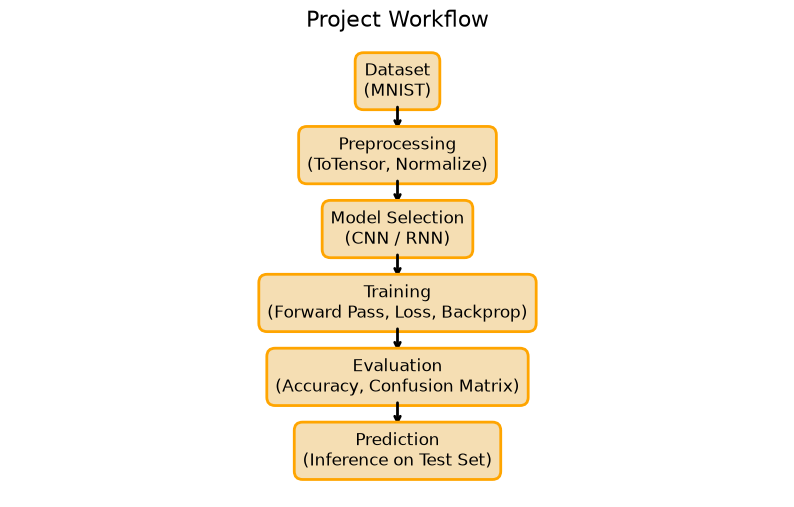

In [19]:
def draw_workflow(save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    
    steps = [
        "Dataset\n(MNIST)",
        "Preprocessing\n(ToTensor, Normalize)",
        "Model Selection\n(CNN / RNN)",
        "Training\n(Forward Pass, Loss, Backprop)",
        "Evaluation\n(Accuracy, Confusion Matrix)",
        "Prediction\n(Inference on Test Set)"
    ]
    
    y_positions = np.linspace(0.9, 0.1, len(steps))
    
    for i, (step, y) in enumerate(zip(steps, y_positions)):
        bbox_props = dict(boxstyle="round,pad=0.5", fc="wheat", ec="orange", lw=2)
        ax.text(0.5, y, step, ha="center", va="center", size=12, bbox=bbox_props)
        if i < len(steps) - 1:
            ax.annotate('', xy=(0.5, y_positions[i+1]+0.05), xytext=(0.5, y-0.05),
                        arrowprops=dict(arrowstyle="->", lw=2))
            
    plt.title("Project Workflow", fontsize=16)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

draw_workflow('images/workflow.png')


## 16. Conclusion

**Why CNN performs better on image classification:**
CNNs are intrinsically designed to handle grid-like data topologies such as images. Through convolutional layers, they exploit spatial hierarchies, capturing local patterns like edges and textures irrespective of their position in the image. This translation invariance and shared parameter scheme make them highly efficient and accurate for image classification tasks, as demonstrated by the superior accuracy achieved in this project.

**When RNNs are useful:**
While RNNs were less accurate for this image classification task, they are incredibly powerful for sequential data. They maintain a hidden state that captures information from previous timesteps, making them the architecture of choice for Time Series Forecasting, Natural Language Processing (NLP), and Speech Recognition. In this project, treating the image rows as a sequence proved that RNNs can learn patterns, but they lack the spatial awareness inherent to CNNs.

**Real-world applications:**
- **CNNs:** Facial recognition, medical image analysis, autonomous vehicles, and object detection.
- **RNNs:** Language translation, sentiment analysis, stock market prediction, and text generation.


## 17. Future Improvements

To further enhance this portfolio project, the following improvements can be explored:
- **Data Augmentation:** Apply random rotations, scaling, and translations to make the models more robust.
- **Advanced Architectures:** Implement advanced CNNs like ResNet or DenseNet, or use Vision Transformers (ViT) for comparison.
- **Transfer Learning:** Utilize pre-trained models (though less relevant for MNIST, highly applicable to complex datasets like CIFAR-10 or ImageNet).
- **Hyperparameter Tuning:** Use libraries like Optuna or Ray Tune to systematically find the optimal learning rate, batch size, and architecture sizes.
- **TensorBoard Integration:** Track training metrics dynamically using TensorBoard instead of static plots.
- **Model Deployment:** Export the best model using ONNX and deploy it as a REST API using FastAPI or a web app using Streamlit.
